<a href="https://colab.research.google.com/github/nasywafunnisa/pengolahan-citra-digital/blob/main/Latihan5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PRAKTIKUM 5.1: IMPLEMENTASI KONVOLUSI MANUAL
Identity kernel applied successfully
Mean 3x3 kernel applied successfully
Sharpen kernel applied successfully
Edge Detection kernel applied successfully
Gaussian 3x3 kernel applied successfully


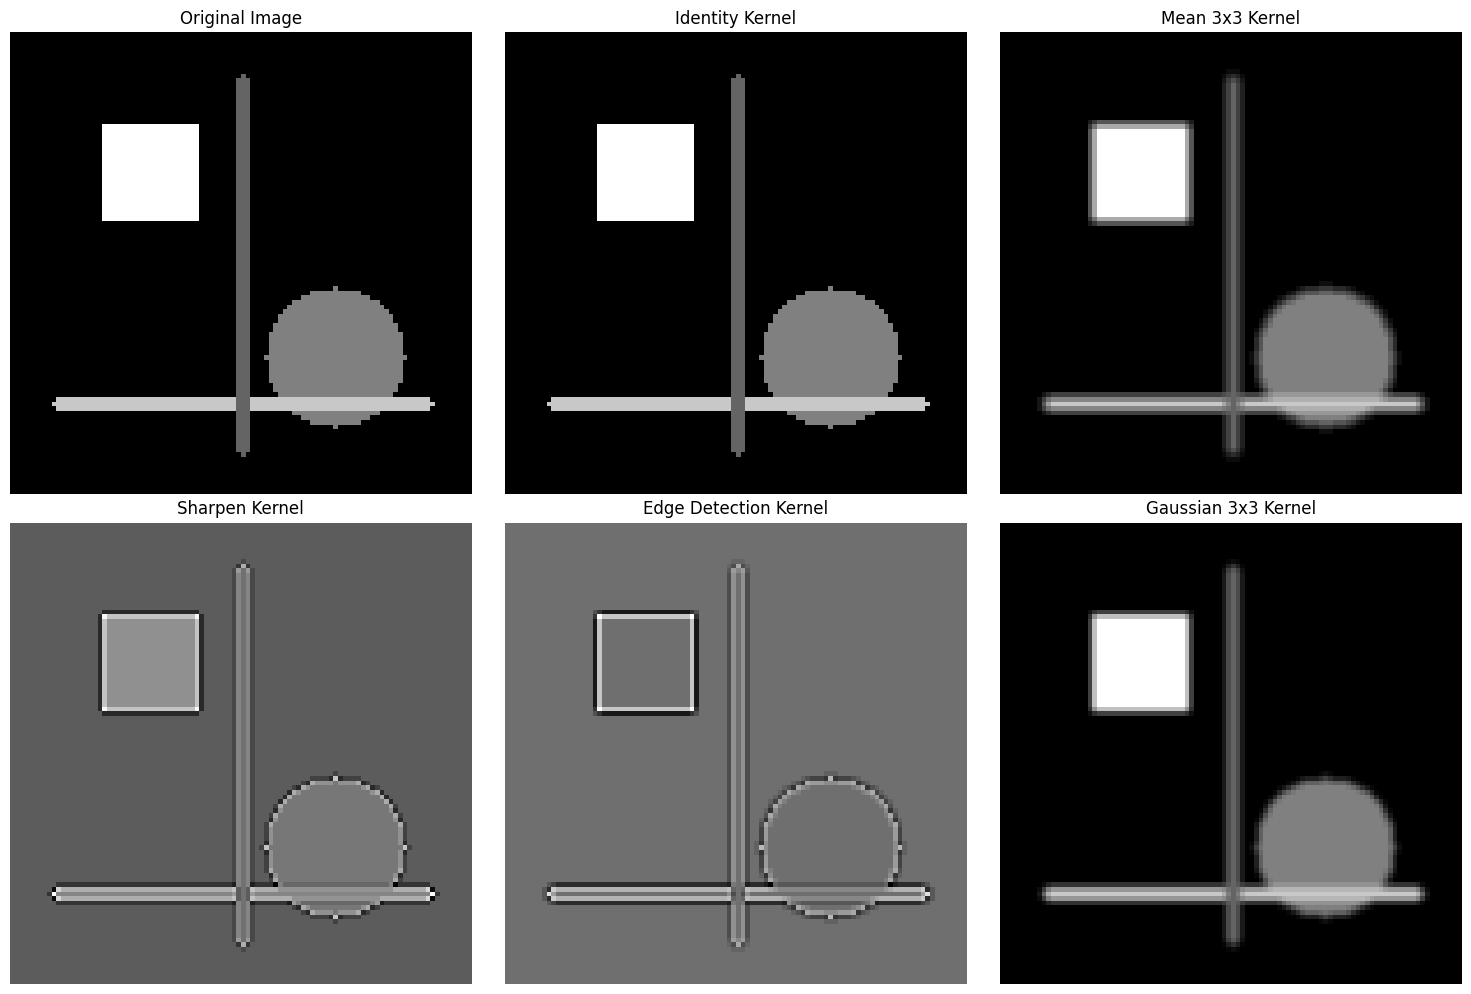

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def manual_convolution(image, kernel):
    """
    Implementasi manual operasi konvolusi
    """
    # Dapatkan dimensi
    img_h, img_w = image.shape
    kernel_h, kernel_w = kernel.shape

    # Hitung padding
    pad_h = kernel_h // 2
    pad_w = kernel_w // 2

    # Buat image dengan zero padding
    padded_img = np.zeros((img_h + 2*pad_h, img_w + 2*pad_w))
    padded_img[pad_h:pad_h+img_h, pad_w:pad_w+img_w] = image

    # Inisialisasi output
    output = np.zeros_like(image, dtype=np.float32)

    # Lakukan konvolusi
    for i in range(img_h):
        for j in range(img_w):
            # Ambil region of interest
            region = padded_img[i:i+kernel_h, j:j+kernel_w]
            # Hitung sum of product
            output[i, j] = np.sum(region * kernel)

    return output

# Membuat citra test pattern
def create_test_pattern(size=100):
    """Membuat citra test pattern dengan edge yang jelas"""
    img = np.zeros((size, size), dtype=np.float32)

    # Add different patterns
    cv2.rectangle(img, (20, 20), (40, 40), 255, -1)  # White square
    cv2.circle(img, (70, 70), 15, 128, -1)  # Gray circle
    cv2.line(img, (10, 80), (90, 80), 200, 2)  # Horizontal line
    cv2.line(img, (50, 10), (50, 90), 100, 2)  # Vertical line

    return img

# Define different kernels
kernels = {
    'Identity': np.array([[0, 0, 0],
                          [0, 1, 0],
                          [0, 0, 0]]),

    'Mean 3x3': np.array([[1, 1, 1],
                          [1, 1, 1],
                          [1, 1, 1]]) / 9,

    'Sharpen': np.array([[0, -1, 0],
                         [-1, 5, -1],
                         [0, -1, 0]]),

    'Edge Detection': np.array([[-1, -1, -1],
                                [-1, 8, -1],
                                [-1, -1, -1]]),

    'Gaussian 3x3': np.array([[1, 2, 1],
                              [2, 4, 2],
                              [1, 2, 1]]) / 16
}

# Praktikum konvolusi
print("PRAKTIKUM 5.1: IMPLEMENTASI KONVOLUSI MANUAL")
print("=" * 50)

# Create test image
test_image = create_test_pattern(100)

# Visualize results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

# Original image
axes[0].imshow(test_image, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Image')
axes[0].axis('off')

# Apply each kernel
for idx, (kernel_name, kernel) in enumerate(list(kernels.items())[:5]):
    result = manual_convolution(test_image, kernel)

    axes[idx+1].imshow(result, cmap='gray')
    axes[idx+1].set_title(f'{kernel_name} Kernel')
    axes[idx+1].axis('off')

    print(f"{kernel_name} kernel applied successfully")

plt.tight_layout()
plt.show()


PRAKTIKUM 5.2: PERBANDINGAN FILTER LINEAR


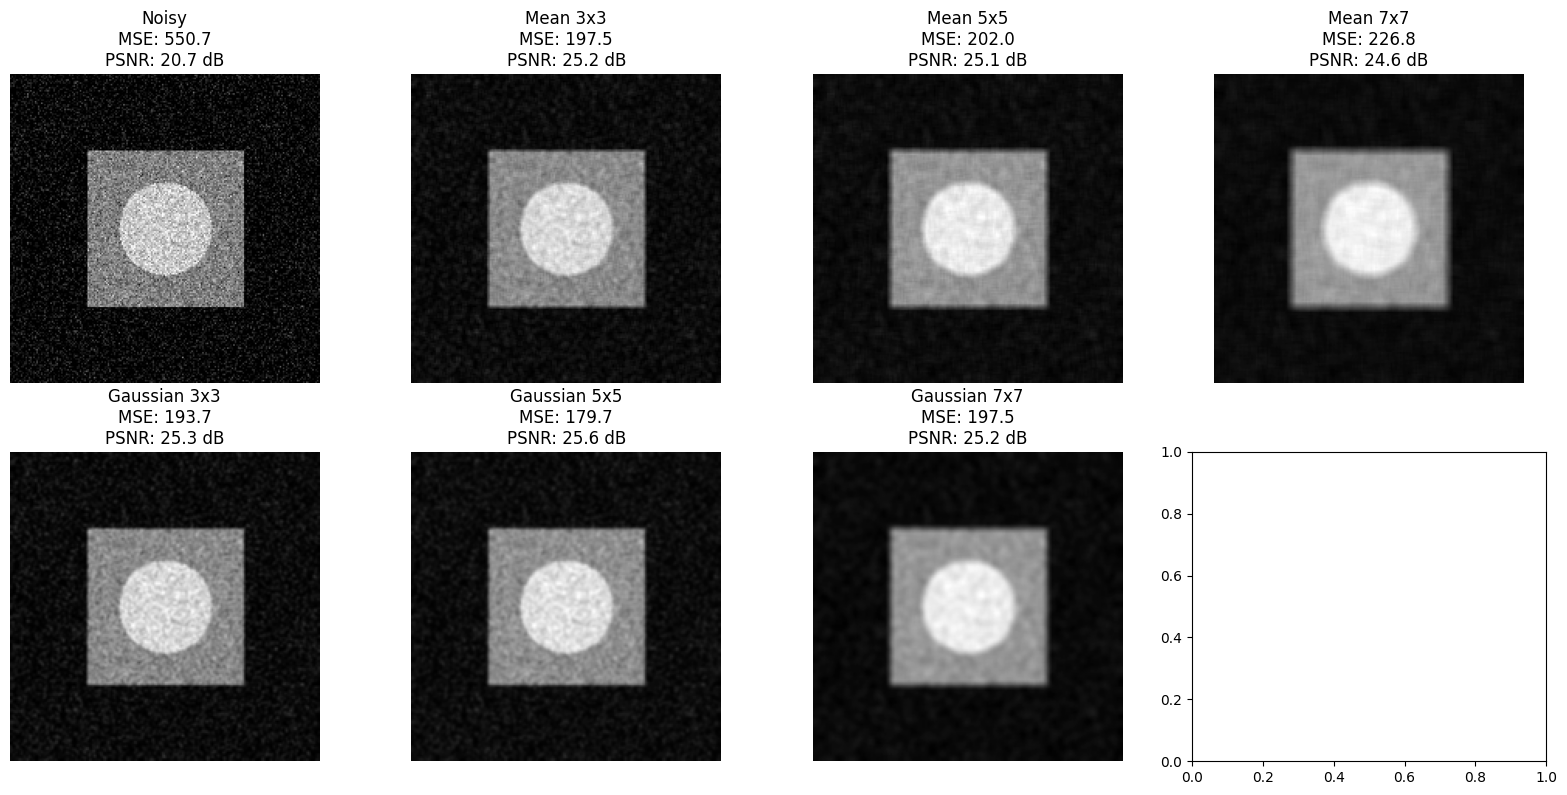


PERFORMANCE COMPARISON OF LINEAR FILTERS
------------------------------------------------------------
Filter          MSE          PSNR (dB)   
------------------------------------------------------------
Noisy           550.65       20.72       
Mean 3x3        197.54       25.17       
Mean 5x5        201.97       25.08       
Mean 7x7        226.85       24.57       
Gaussian 3x3    193.67       25.26       
Gaussian 5x5    179.68       25.59       
Gaussian 7x7    197.50       25.18       


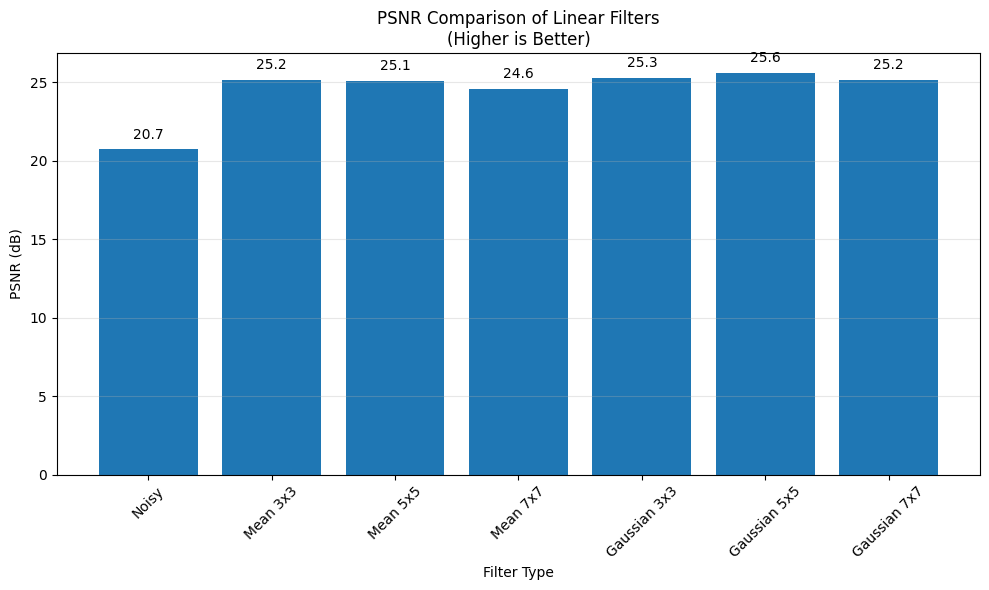

In [2]:
def compare_linear_filters():
    """
    Perbandingan performa berbagai filter linear
    """
    print("\nPRAKTIKUM 5.2: PERBANDINGAN FILTER LINEAR")
    print("=" * 50)

    # Create noisy image
    clean_img = np.zeros((200, 200), dtype=np.uint8)
    cv2.rectangle(clean_img, (50, 50), (150, 150), 128, -1)
    cv2.circle(clean_img, (100, 100), 30, 200, -1)

    # Add Gaussian noise
    noise = np.random.normal(0, 30, clean_img.shape)
    noisy_img = np.clip(clean_img.astype(float) + noise, 0, 255).astype(np.uint8)

    # Apply different linear filters
    filters = {
        'Noisy': lambda x: x,
        'Mean 3x3': lambda x: cv2.blur(x, (3, 3)),
        'Mean 5x5': lambda x: cv2.blur(x, (5, 5)),
        'Mean 7x7': lambda x: cv2.blur(x, (7, 7)),
        'Gaussian 3x3': lambda x: cv2.GaussianBlur(x, (3, 3), 0),
        'Gaussian 5x5': lambda x: cv2.GaussianBlur(x, (5, 5), 1),
        'Gaussian 7x7': lambda x: cv2.GaussianBlur(x, (7, 7), 2)
    }

    # Calculate metrics
    results = []

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()

    for idx, (filter_name, filter_func) in enumerate(filters.items()):
        filtered_img = filter_func(noisy_img)

        # Calculate metrics
        mse = np.mean((clean_img.astype(float) - filtered_img.astype(float)) ** 2)
        psnr = 10 * np.log10(255**2 / mse) if mse > 0 else float('inf')

        results.append({
            'filter': filter_name,
            'mse': mse,
            'psnr': psnr
        })

        # Display
        axes[idx].imshow(filtered_img, cmap='gray')
        axes[idx].set_title(f'{filter_name}\nMSE: {mse:.1f}\nPSNR: {psnr:.1f} dB')
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

    # Display comparison table
    print("\nPERFORMANCE COMPARISON OF LINEAR FILTERS")
    print("-" * 60)
    print(f"{'Filter':<15} {'MSE':<12} {'PSNR (dB)':<12}")
    print("-" * 60)

    for result in results:
        print(f"{result['filter']:<15} {result['mse']:<12.2f} {result['psnr']:<12.2f}")

    # Visual comparison of PSNR
    fig, ax = plt.subplots(figsize=(10, 6))
    filter_names = [r['filter'] for r in results]
    psnr_values = [r['psnr'] for r in results]

    bars = ax.bar(filter_names, psnr_values)
    ax.set_xlabel('Filter Type')
    ax.set_ylabel('PSNR (dB)')
    ax.set_title('PSNR Comparison of Linear Filters\n(Higher is Better)')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

    # Add value labels
    for bar, psnr in zip(bars, psnr_values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
               f'{psnr:.1f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    return results

linear_filter_results = compare_linear_filters()


PRAKTIKUM 5.3: FILTER NON-LINEAR UNTUK SALT-AND-PEPPER NOISE


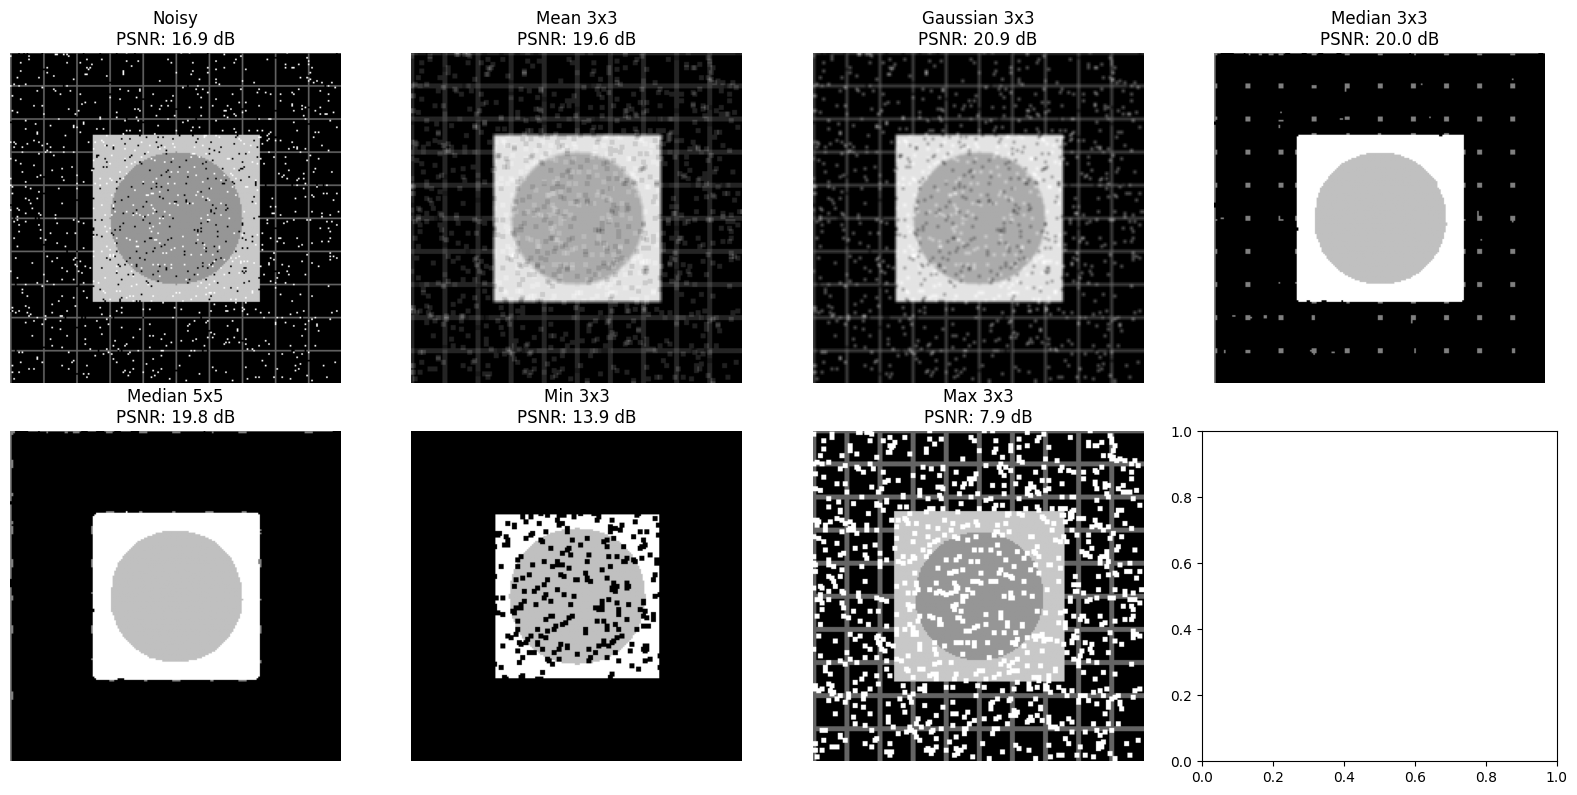


ANALYSIS OF NON-LINEAR FILTERS FOR SALT-AND-PEPPER NOISE
----------------------------------------------------------------------
Observation:
1. Median filter performs best for salt-and-pepper noise
2. Linear filters (mean, Gaussian) blur the image and don't remove noise effectively
3. Min filter removes salt noise but darkens the image
4. Max filter removes pepper noise but brightens the image


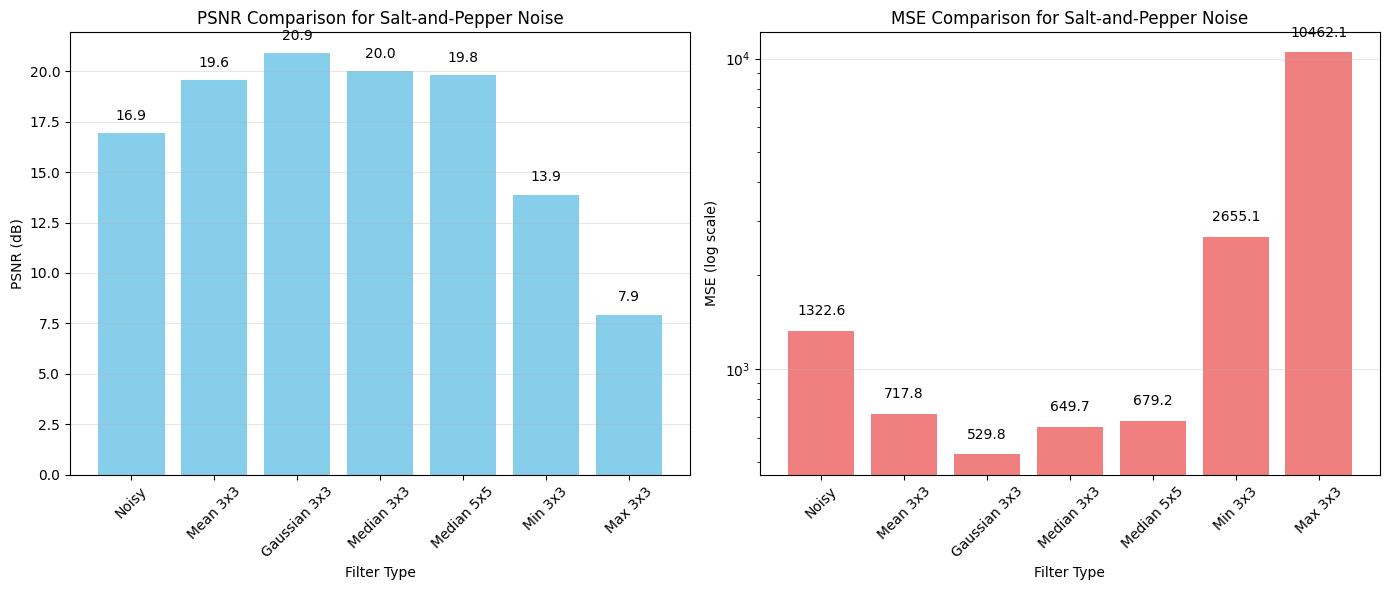

In [3]:
def nonlinear_filters_demo():
    """
    Demonstrasi filter non-linear untuk salt-and-pepper noise
    """
    print("\nPRAKTIKUM 5.3: FILTER NON-LINEAR UNTUK SALT-AND-PEPPER NOISE")
    print("=" * 60)

    # Create clean image with texture
    clean_img = np.zeros((200, 200), dtype=np.uint8)

    # Add texture pattern
    for i in range(0, 200, 20):
        cv2.line(clean_img, (i, 0), (i, 199), 100, 1)
        cv2.line(clean_img, (0, i), (199, i), 100, 1)

    cv2.rectangle(clean_img, (50, 50), (150, 150), 200, -1)
    cv2.circle(clean_img, (100, 100), 40, 150, -1)

    # Add salt-and-pepper noise
    def add_salt_pepper_noise(image, prob=0.05):
        noisy = image.copy()
        total_pixels = image.size

        # Salt noise
        num_salt = int(total_pixels * prob / 2)
        salt_coords = [np.random.randint(0, i-1, num_salt) for i in image.shape]
        noisy[salt_coords[0], salt_coords[1]] = 255

        # Pepper noise
        num_pepper = int(total_pixels * prob / 2)
        pepper_coords = [np.random.randint(0, i-1, num_pepper) for i in image.shape]
        noisy[pepper_coords[0], pepper_coords[1]] = 0

        return noisy

    noisy_img = add_salt_pepper_noise(clean_img, prob=0.05)

    # Apply different filters
    filters = {
        'Noisy': lambda x: x,
        'Mean 3x3': lambda x: cv2.blur(x, (3, 3)),
        'Gaussian 3x3': lambda x: cv2.GaussianBlur(x, (3, 3), 0),
        'Median 3x3': lambda x: cv2.medianBlur(x, 3),
        'Median 5x5': lambda x: cv2.medianBlur(x, 5),
        'Min 3x3': lambda x: cv2.erode(x, np.ones((3, 3))),
        'Max 3x3': lambda x: cv2.dilate(x, np.ones((3, 3)))
    }

    # Apply filters and calculate metrics
    results = []

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()

    for idx, (filter_name, filter_func) in enumerate(filters.items()):
        filtered_img = filter_func(noisy_img)

        # Calculate metrics
        mse = np.mean((clean_img.astype(float) - filtered_img.astype(float)) ** 2)
        psnr = 10 * np.log10(255**2 / mse) if mse > 0 else float('inf')

        results.append({
            'filter': filter_name,
            'mse': mse,
            'psnr': psnr
        })

        # Display
        axes[idx].imshow(filtered_img, cmap='gray')
        axes[idx].set_title(f'{filter_name}\nPSNR: {psnr:.1f} dB')
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

    # Analysis of results
    print("\nANALYSIS OF NON-LINEAR FILTERS FOR SALT-AND-PEPPER NOISE")
    print("-" * 70)
    print("Observation:")
    print("1. Median filter performs best for salt-and-pepper noise")
    print("2. Linear filters (mean, Gaussian) blur the image and don't remove noise effectively")
    print("3. Min filter removes salt noise but darkens the image")
    print("4. Max filter removes pepper noise but brightens the image")

    # Visual comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # PSNR comparison
    filter_names = [r['filter'] for r in results]
    psnr_values = [r['psnr'] for r in results]

    bars1 = ax1.bar(filter_names, psnr_values, color='skyblue')
    ax1.set_xlabel('Filter Type')
    ax1.set_ylabel('PSNR (dB)')
    ax1.set_title('PSNR Comparison for Salt-and-Pepper Noise')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3, axis='y')

    for bar, psnr in zip(bars1, psnr_values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{psnr:.1f}', ha='center', va='bottom')

    # MSE comparison (log scale)
    mse_values = [r['mse'] for r in results]
    bars2 = ax2.bar(filter_names, mse_values, color='lightcoral')
    ax2.set_xlabel('Filter Type')
    ax2.set_ylabel('MSE (log scale)')
    ax2.set_title('MSE Comparison for Salt-and-Pepper Noise')
    ax2.set_yscale('log')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3, axis='y')

    for bar, mse in zip(bars2, mse_values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                f'{mse:.1f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    return results

nonlinear_filter_results = nonlinear_filters_demo()


PRAKTIKUM 5.4: ADAPTIVE DAN HYBRID FILTERING


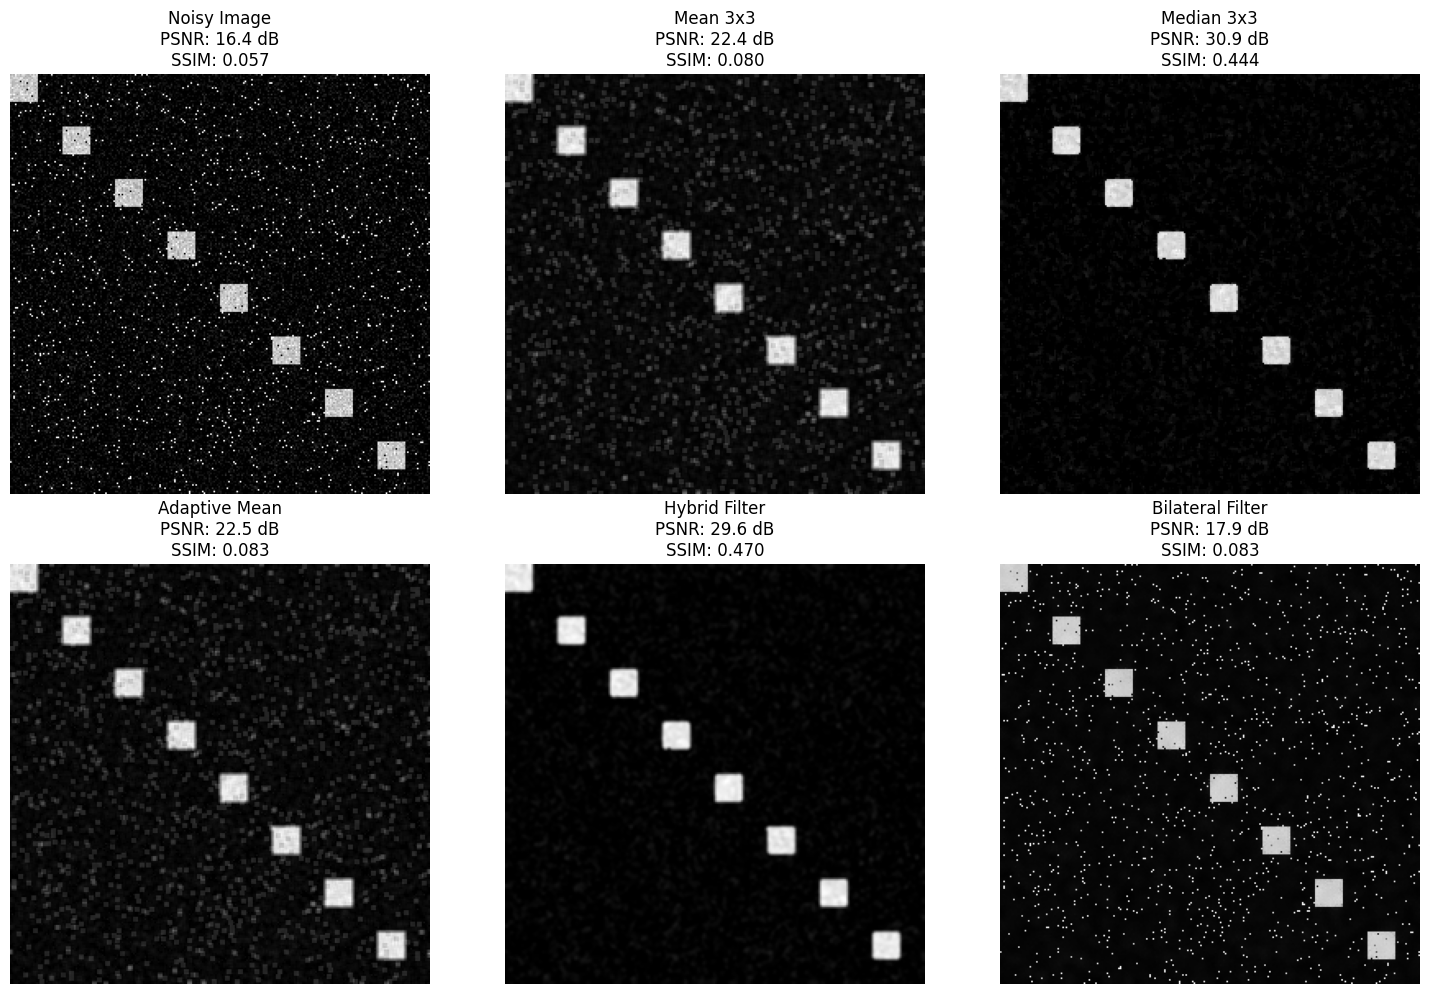


ADVANCED FILTERS PERFORMANCE COMPARISON
--------------------------------------------------------------------------------
Filter               MSE          PSNR (dB)    SSIM        
--------------------------------------------------------------------------------
Noisy Image          1493.75      16.39        0.057       
Mean 3x3             373.24       22.41        0.080       
Median 3x3           52.83        30.90        0.444       
Adaptive Mean        365.59       22.50        0.083       
Hybrid Filter        71.20        29.61        0.470       
Bilateral Filter     1062.41      17.87        0.083       


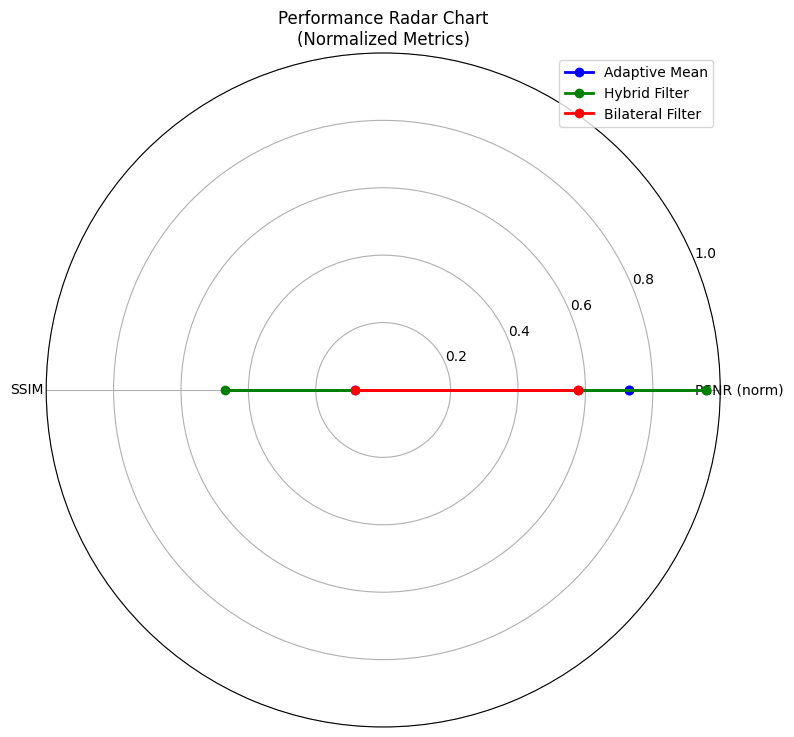

In [4]:
def adaptive_hybrid_filters():
    """
    Demonstrasi adaptive dan hybrid filtering approaches
    """
    print("\nPRAKTIKUM 5.4: ADAPTIVE DAN HYBRID FILTERING")
    print("=" * 50)

    # Create test image with mixed noise
    clean_img = np.zeros((256, 256), dtype=np.uint8)

    # Create pattern
    for i in range(0, 256, 32):
        cv2.rectangle(clean_img, (i, i), (i+16, i+16), 200, -1)

    # Add mixed noise (Gaussian + Salt-and-Pepper)
    noisy_img = clean_img.copy().astype(float)

    # Gaussian noise
    gaussian_noise = np.random.normal(0, 20, clean_img.shape)
    noisy_img += gaussian_noise

    # Salt-and-pepper noise
    salt_pepper = np.random.random(clean_img.shape)
    noisy_img[salt_pepper < 0.02] = 255  # Salt
    noisy_img[salt_pepper > 0.98] = 0    # Pepper

    noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

    # Define custom filters
    def adaptive_mean_filter(image, window_size=3, threshold=30):
        """
        Adaptive mean filter based on local variance
        """
        h, w = image.shape
        output = image.copy().astype(float)

        pad = window_size // 2
        padded = cv2.copyMakeBorder(image, pad, pad, pad, pad, cv2.BORDER_REFLECT)

        for i in range(h):
            for j in range(w):
                window = padded[i:i+window_size, j:j+window_size]
                local_mean = np.mean(window)
                local_var = np.var(window)

                # Apply filter only if variance is high (likely noise)
                if local_var > threshold:
                    output[i, j] = local_mean

        return np.clip(output, 0, 255).astype(np.uint8)

    def hybrid_filter(image):
        """
        Hybrid filter: median followed by Gaussian
        """
        # First pass: median for salt-and-pepper
        median_filtered = cv2.medianBlur(image, 3)
        # Second pass: Gaussian for Gaussian noise
        gaussian_filtered = cv2.GaussianBlur(median_filtered, (3, 3), 0)
        return gaussian_filtered

    def bilateral_filter_custom(image, d=9, sigma_color=75, sigma_space=75):
        """
        Bilateral filter (edge-preserving smoothing)
        """
        return cv2.bilateralFilter(image, d, sigma_color, sigma_space)

    # Apply different advanced filters
    filters = {
        'Noisy Image': lambda x: x,
        'Mean 3x3': lambda x: cv2.blur(x, (3, 3)),
        'Median 3x3': lambda x: cv2.medianBlur(x, 3),
        'Adaptive Mean': lambda x: adaptive_mean_filter(x, 3, 30),
        'Hybrid Filter': lambda x: hybrid_filter(x),
        'Bilateral Filter': lambda x: bilateral_filter_custom(x)
    }

    # Apply and evaluate
    results = []

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()

    for idx, (filter_name, filter_func) in enumerate(filters.items()):
        filtered_img = filter_func(noisy_img)

        # Calculate multiple metrics
        mse = np.mean((clean_img.astype(float) - filtered_img.astype(float)) ** 2)
        psnr = 10 * np.log10(255**2 / mse) if mse > 0 else float('inf')

        # SSIM (simplified)
        def calculate_ssim(img1, img2):
            C1 = (0.01 * 255) ** 2
            C2 = (0.03 * 255) ** 2

            mu1 = cv2.GaussianBlur(img1.astype(float), (11, 11), 1.5)
            mu2 = cv2.GaussianBlur(img2.astype(float), (11, 11), 1.5)

            mu1_sq = mu1 ** 2
            mu2_sq = mu2 ** 2
            mu1_mu2 = mu1 * mu2

            sigma1_sq = cv2.GaussianBlur(img1.astype(float) ** 2, (11, 11), 1.5) - mu1_sq
            sigma2_sq = cv2.GaussianBlur(img2.astype(float) ** 2, (11, 11), 1.5) - mu2_sq
            sigma12 = cv2.GaussianBlur(img1.astype(float) * img2.astype(float), (11, 11), 1.5) - mu1_mu2

            ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
            return np.mean(ssim_map)

        ssim = calculate_ssim(clean_img, filtered_img)

        results.append({
            'filter': filter_name,
            'mse': mse,
            'psnr': psnr,
            'ssim': ssim
        })

        # Display
        axes[idx].imshow(filtered_img, cmap='gray')
        axes[idx].set_title(f'{filter_name}\nPSNR: {psnr:.1f} dB\nSSIM: {ssim:.3f}')
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

    # Performance comparison table
    print("\nADVANCED FILTERS PERFORMANCE COMPARISON")
    print("-" * 80)
    print(f"{'Filter':<20} {'MSE':<12} {'PSNR (dB)':<12} {'SSIM':<12}")
    print("-" * 80)

    for result in results:
        print(f"{result['filter']:<20} {result['mse']:<12.2f} {result['psnr']:<12.2f} {result['ssim']:<12.3f}")

    # Radar chart comparison
    from matplotlib.patches import Circle

    # Normalize metrics for radar chart
    metrics = ['PSNR', 'SSIM']

    # Invert MSE (higher is worse, so we use 1/MSE)
    mse_values = [r['mse'] for r in results]
    max_mse = max(mse_values)
    inv_mse = [1 - (mse / max_mse) for mse in mse_values]

    psnr_values = [r['psnr'] for r in results]
    max_psnr = max(psnr_values)
    norm_psnr = [psnr / max_psnr for psnr in psnr_values]

    ssim_values = [r['ssim'] for r in results]
    norm_ssim = ssim_values  # SSIM already 0-1

    # Select top filters for radar chart
    top_filters = ['Adaptive Mean', 'Hybrid Filter', 'Bilateral Filter']
    top_indices = [list(filters.keys()).index(f) for f in top_filters]

    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]  # Close the polygon

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    colors = ['blue', 'green', 'red']

    for idx, filter_idx in enumerate(top_indices):
        values = [norm_psnr[filter_idx], ssim_values[filter_idx]]
        values += values[:1]  # Close the polygon

        ax.plot(angles, values, 'o-', linewidth=2, label=top_filters[idx], color=colors[idx])
        ax.fill(angles, values, alpha=0.1, color=colors[idx])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(['PSNR (norm)', 'SSIM'])
    ax.set_ylim(0, 1)
    ax.set_title('Performance Radar Chart\n(Normalized Metrics)')
    ax.legend(loc='upper right')
    ax.grid(True)

    plt.tight_layout()
    plt.show()

    return results

advanced_filter_results = adaptive_hybrid_filters()